# Packet to Image Conversion for Computer Vision Analysis

This notebook demonstrates various strategies for converting network packet bytes into image representations for malware detection using computer vision techniques.

In [1]:
# Import required libraries
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import time

from src.data.packet_to_image import (
    PacketToImageConverter, 
    EncodingStrategy,
    create_batch_generator
)
from src.data.sample_data_generator import SampleDataGenerator

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Generate Sample Packet Data

First, let's generate some sample packet data to work with.

In [2]:
# Initialize data generator
generator = SampleDataGenerator()

# Generate sample packets
n_samples = 100
packets, labels = generator.generate_packet_data(
    n_samples=n_samples,
    benign_ratio=0.7,
    packet_size_range=(256, 1500)
)

print(f"Generated {len(packets)} packets")
print(f"Benign: {sum(labels == 0)}, Malicious: {sum(labels == 1)}")
print(f"Packet sizes: {[len(p) for p in packets[:5]]}")

Generated 100 packets
Benign: 70, Malicious: 30
Packet sizes: [991, 705, 802, 511, 1196]


## 2. Basic Packet to Image Conversion

Let's convert a single packet to an image using different encoding strategies.

Sample packet size: 991 bytes


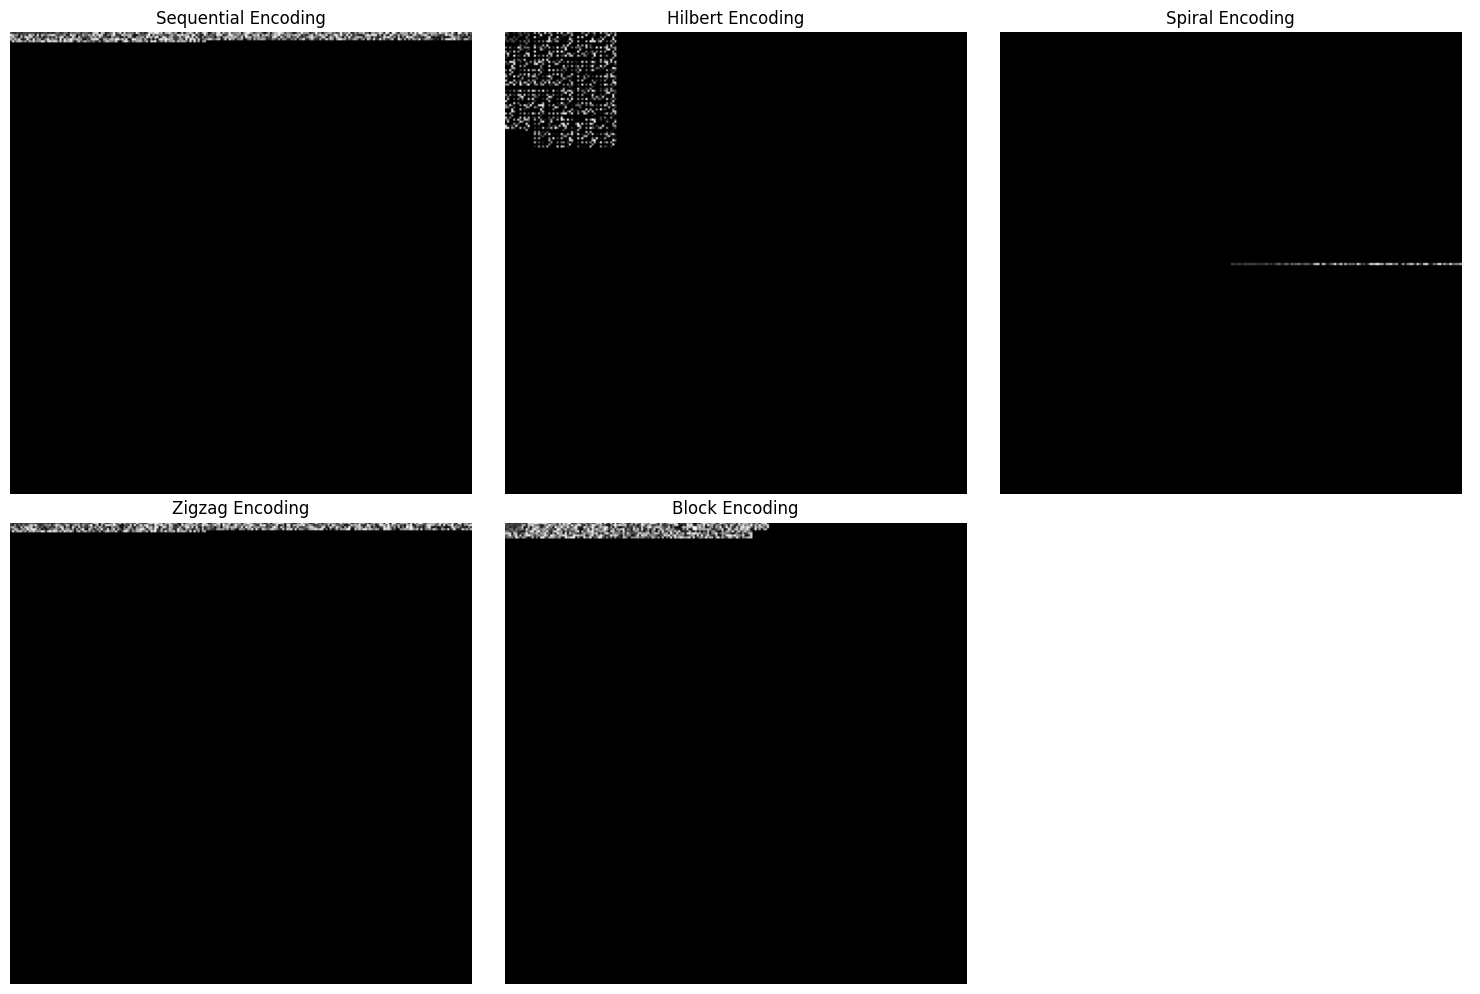

In [3]:
# Initialize converter
converter = PacketToImageConverter(default_image_size=(224, 224))

# Select a sample packet
sample_packet = packets[0]
print(f"Sample packet size: {len(sample_packet)} bytes")

# Convert using different strategies
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
strategies = list(EncodingStrategy)

for idx, (ax, strategy) in enumerate(zip(axes.flat, strategies)):
    # Convert packet to image
    image_tensor = converter.packet_to_image(
        sample_packet, 
        strategy=strategy,
        normalize=False  # Keep original byte values for visualization
    )
    
    # Convert to numpy for plotting
    image = image_tensor.squeeze().numpy()
    
    # Plot
    im = ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{strategy.value.capitalize()} Encoding')
    ax.axis('off')

# Hide the extra empty subplot
if len(strategies) < len(axes.flat):
    axes.flat[len(strategies)].axis('off')
    
plt.tight_layout()
plt.show()

## 3. Batch Processing Performance

Let's test the performance of batch processing for different encoding strategies.

Encoding Time (milliseconds) by Packet Size and Strategy:
Strategy      block  hilbert  sequential  spiral  zigzag
Packet Size                                             
256          13.857   11.501       0.129   6.592  13.707
512          14.753   11.437       0.067   6.873  14.117
1024         13.536   11.301       0.079   6.846  13.824
2048         12.970   12.446       0.073   6.250  14.492
4096         13.958   12.264       0.073   6.126  14.234


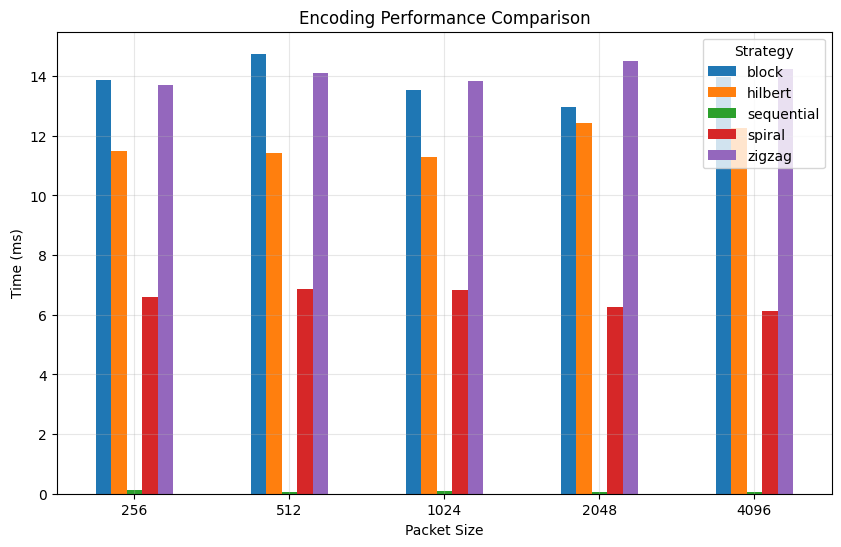

In [4]:
# Benchmark encoding speeds
benchmark_results = converter.benchmark_encoding_speeds(
    packet_sizes=[256, 512, 1024, 2048, 4096]
)

# Display results
import pandas as pd

# Convert to DataFrame for better visualization
results_data = []
for packet_size, strategies in benchmark_results.items():
    for strategy, time_taken in strategies.items():
        results_data.append({
            'Packet Size': int(packet_size.split('_')[-1]),
            'Strategy': strategy,
            'Time (ms)': time_taken * 1000
        })

df_results = pd.DataFrame(results_data)
pivot_table = df_results.pivot(index='Packet Size', columns='Strategy', values='Time (ms)')

print("Encoding Time (milliseconds) by Packet Size and Strategy:")
print(pivot_table.round(3))

# Plot performance comparison
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Time (ms)')
plt.title('Encoding Performance Comparison')
plt.xticks(rotation=0)
plt.legend(title='Strategy')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Batch Conversion and DataLoader Integration

Let's demonstrate batch conversion and PyTorch DataLoader integration.

In [5]:
# Convert batch of packets
batch_size = 32
batch_packets = packets[:batch_size]

# Time batch conversion
start_time = time.time()
batch_images = converter.packets_to_images(
    batch_packets,
    strategy=EncodingStrategy.SEQUENTIAL,
    normalize=True
)
batch_time = time.time() - start_time

print(f"Batch shape: {batch_images.shape}")
print(f"Batch conversion time: {batch_time:.3f} seconds")
print(f"Average time per packet: {batch_time/batch_size*1000:.3f} ms")

# Create DataLoader
dataloader = create_batch_generator(
    packets,
    labels,
    batch_size=16,
    image_size=(224, 224),
    strategy=EncodingStrategy.SEQUENTIAL,
    shuffle=True
)

# Test DataLoader
print(f"\nDataLoader created with {len(dataloader)} batches")

# Get one batch
for batch_images, batch_labels in dataloader:
    print(f"Batch images shape: {batch_images.shape}")
    print(f"Batch labels shape: {batch_labels.shape}")
    print(f"Label distribution: {torch.bincount(batch_labels)}")
    break

Batch shape: torch.Size([32, 1, 224, 224])
Batch conversion time: 0.009 seconds
Average time per packet: 0.295 ms

DataLoader created with 7 batches
Batch images shape: torch.Size([16, 1, 224, 224])
Batch labels shape: torch.Size([16])
Label distribution: tensor([10,  6])


/home/ubuntu/analyst/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


## 5. Memory Optimization Analysis

Let's analyze memory usage for different configurations.

Memory Usage (MB) by Batch Size and Image Size:
Image Size  128x128  224x224  256x256  64x64
Batch Size                                  
16              1.0      3.1      4.0    0.2
32              2.0      6.1      8.0    0.5
64              4.0     12.2     16.0    1.0
128             8.0     24.5     32.0    2.0


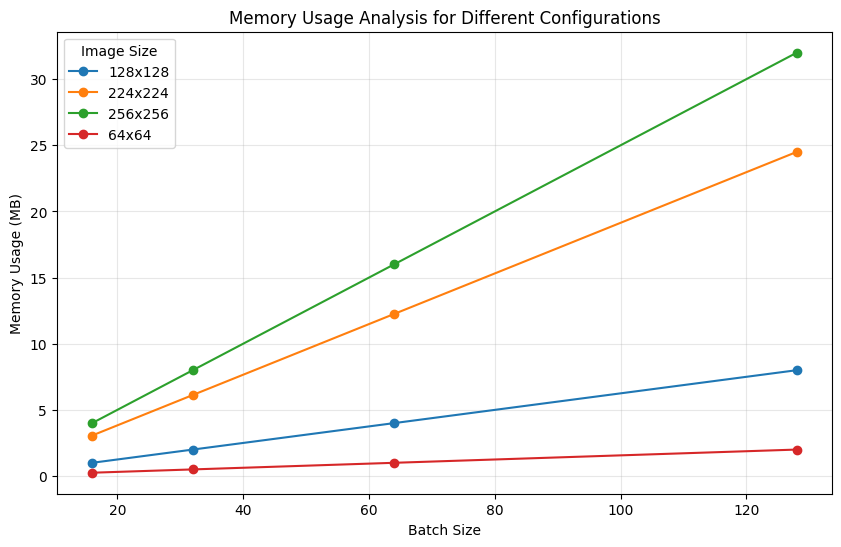

In [6]:
# Test different image sizes and batch sizes
image_sizes = [(64, 64), (128, 128), (224, 224), (256, 256)]
batch_sizes = [16, 32, 64, 128]

memory_analysis = []

for img_size in image_sizes:
    converter_test = PacketToImageConverter(default_image_size=img_size)
    
    for batch_size in batch_sizes:
        stats = converter_test.optimize_memory_usage(batch_size)
        memory_analysis.append({
            'Image Size': f"{img_size[0]}x{img_size[1]}",
            'Batch Size': batch_size,
            'Memory (MB)': stats['batch_memory_mb'],
            'Pixels per Image': stats['bytes_per_image']
        })

df_memory = pd.DataFrame(memory_analysis)

# Pivot for better visualization
memory_pivot = df_memory.pivot(index='Batch Size', columns='Image Size', values='Memory (MB)')

print("Memory Usage (MB) by Batch Size and Image Size:")
print(memory_pivot.round(1))

# Plot memory usage
memory_pivot.plot(kind='line', marker='o', figsize=(10, 6))
plt.ylabel('Memory Usage (MB)')
plt.xlabel('Batch Size')
plt.title('Memory Usage Analysis for Different Configurations')
plt.grid(True, alpha=0.3)
plt.legend(title='Image Size')
plt.show()

## 6. Visual Comparison of Encoding Strategies

Let's create a more detailed comparison of how different encoding strategies affect the visual representation.

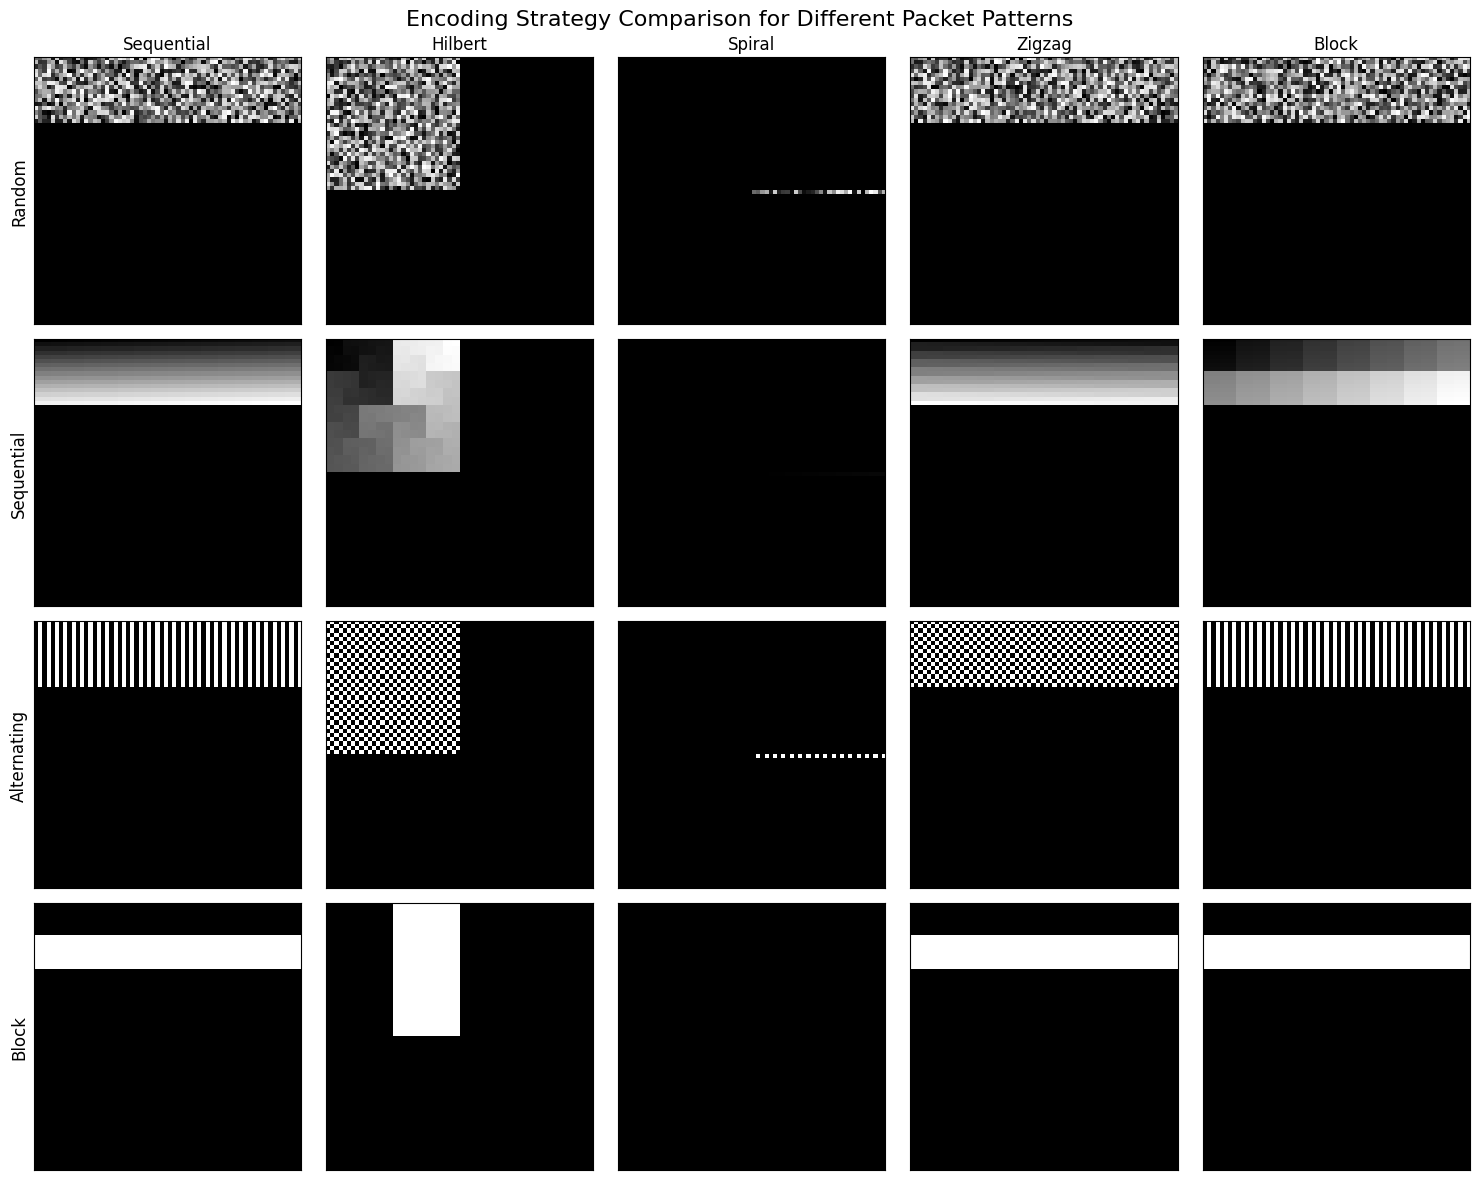

In [7]:
# Generate packets with different characteristics
test_packets = [
    np.random.randint(0, 256, 1024, dtype=np.uint8),  # Random
    np.arange(256, dtype=np.uint8).repeat(4),  # Sequential pattern
    np.array([0, 255] * 512, dtype=np.uint8),  # Alternating pattern
    np.concatenate([np.zeros(512), np.ones(512) * 255]).astype(np.uint8)  # Block pattern
]

packet_names = ['Random', 'Sequential', 'Alternating', 'Block']

# Create visualization - 4 packet types × 5 encoding strategies
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row, (packet, name) in enumerate(zip(test_packets, packet_names)):
    for col, strategy in enumerate(EncodingStrategy):
        # Convert packet
        image_tensor = converter.packet_to_image(
            packet,
            image_size=(64, 64),  # Smaller for visualization
            strategy=strategy,
            normalize=False
        )
        
        # Plot
        ax = axes[row, col]
        image = image_tensor.squeeze().numpy()
        ax.imshow(image, cmap='gray', vmin=0, vmax=255)
        
        if row == 0:
            ax.set_title(strategy.value.capitalize())
        if col == 0:
            ax.set_ylabel(name, fontsize=12)
            
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Encoding Strategy Comparison for Different Packet Patterns', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Integration Example with Feature Extraction

Let's demonstrate how packet-to-image conversion can be integrated with feature extraction.

In [8]:
from torchvision import transforms, models
import torch.nn as nn

# Define a simple feature extractor using pretrained ResNet
class PacketImageFeatureExtractor:
    def __init__(self, model_name='resnet18', output_features=512):
        # Load pretrained model
        self.model = getattr(models, model_name)(pretrained=True)
        
        # Remove the final classification layer
        self.model = nn.Sequential(*list(self.model.children())[:-1])
        
        # Set to evaluation mode
        self.model.eval()
        
        # Define transforms for grayscale to RGB
        self.transform = transforms.Compose([
            transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
    def extract_features(self, packet_images):
        """Extract features from packet images using pretrained CNN"""
        # Apply transforms
        transformed = torch.stack([self.transform(img) for img in packet_images])
        
        # Extract features
        with torch.no_grad():
            features = self.model(transformed)
            features = features.squeeze()
            
        return features

# Initialize feature extractor
feature_extractor = PacketImageFeatureExtractor()

# Convert packets to images
sample_images = converter.packets_to_images(
    packets[:10],
    strategy=EncodingStrategy.HILBERT,
    normalize=True
)

# Extract features
features = feature_extractor.extract_features(sample_images)

print(f"Extracted features shape: {features.shape}")
print(f"Feature vector size per packet: {features.shape[1]}")
print(f"\nFirst 5 feature values for packet 0: {features[0, :5].numpy()}")

/home/ubuntu/analyst/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ubuntu/analyst/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 11.4MB/s]


Extracted features shape: torch.Size([10, 512])
Feature vector size per packet: 512

First 5 feature values for packet 0: [0.41895875 0.         0.35511586 0.87642235 0.18458812]


## 8. Performance Optimization Strategies

Let's explore different optimization strategies for large-scale processing.

Sequential processing (100 packets): 0.016 seconds
Throughput: 6110.0 packets/second
Batch size 10: 7816.0 packets/second
Batch size 25: 8817.3 packets/second
Batch size 50: 8939.5 packets/second
Batch size 100: 7895.6 packets/second


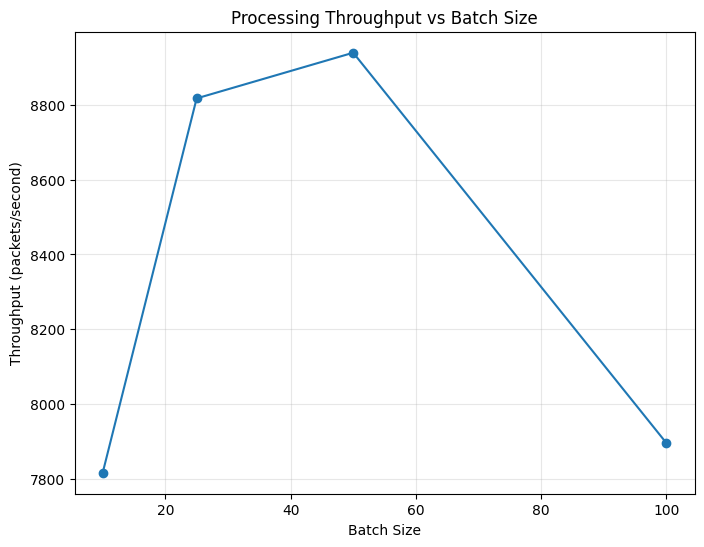

In [9]:
# Test parallel processing
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import multiprocessing

def process_packet_batch(packet_batch, converter, strategy):
    """Process a batch of packets"""
    return converter.packets_to_images(packet_batch, strategy=strategy)

# Generate larger dataset
large_packets = [np.random.randint(0, 256, 1024, dtype=np.uint8) 
                 for _ in range(1000)]

# Sequential processing
start_time = time.time()
sequential_results = converter.packets_to_images(
    large_packets[:100], 
    strategy=EncodingStrategy.SEQUENTIAL
)
sequential_time = time.time() - start_time

print(f"Sequential processing (100 packets): {sequential_time:.3f} seconds")
print(f"Throughput: {100/sequential_time:.1f} packets/second")

# Batch processing with different batch sizes
batch_sizes = [10, 25, 50, 100]
throughputs = []

for batch_size in batch_sizes:
    start_time = time.time()
    
    # Process in batches
    results = []
    for i in range(0, 100, batch_size):
        batch = large_packets[i:i+batch_size]
        batch_result = converter.packets_to_images(
            batch, 
            strategy=EncodingStrategy.SEQUENTIAL
        )
        results.append(batch_result)
    
    batch_time = time.time() - start_time
    throughput = 100 / batch_time
    throughputs.append(throughput)
    
    print(f"Batch size {batch_size}: {throughput:.1f} packets/second")

# Plot throughput comparison
plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, throughputs, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Throughput (packets/second)')
plt.title('Processing Throughput vs Batch Size')
plt.grid(True, alpha=0.3)
plt.show()

## 9. Summary and Best Practices

### Key Findings:

1. **Encoding Strategies**:
   - **Sequential**: Fastest, good for preserving byte order
   - **Hilbert**: Better spatial locality, useful for CNN features
   - **Spiral**: Good for center-focused patterns
   - **Zigzag**: Similar to JPEG encoding, may help with compression artifacts

2. **Performance Considerations**:
   - Batch processing significantly improves throughput
   - Memory usage scales linearly with batch size and image dimensions
   - Consider using smaller image sizes (64x64 or 128x128) for initial experiments

3. **Integration Tips**:
   - Use PyTorch DataLoader for efficient batching and shuffling
   - Leverage pretrained CNN models for feature extraction
   - Consider GPU acceleration for large-scale processing

### Recommended Configuration:

In [10]:
# Recommended configuration for production
recommended_config = {
    'image_size': (224, 224),  # Standard size for pretrained models
    'encoding_strategy': EncodingStrategy.HILBERT,  # Good spatial locality
    'batch_size': 32,  # Balance between memory and throughput
    'normalize': True,  # Required for pretrained models
    'num_workers': 4,  # For DataLoader parallel processing
    'pin_memory': True,  # For GPU transfer optimization
}

print("Recommended Production Configuration:")
for key, value in recommended_config.items():
    print(f"  {key}: {value}")

Recommended Production Configuration:
  image_size: (224, 224)
  encoding_strategy: EncodingStrategy.HILBERT
  batch_size: 32
  normalize: True
  num_workers: 4
  pin_memory: True
